# 1.1 — Football Analytics Explained: The Data Behind Every Touch

This notebook accompanies the blog article. We load real Statsbomb event data, explore its structure, and run first simple queries.

**Match:** Bayer Leverkusen 5–0 Werder Bremen, Bundesliga 2023/24  
**Data source:** Statsbomb Open Data (local)

## Setup

In [1]:
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('/Users/stefanhofmann/Documents/Bewerbung/Portfolio/Blog/assets/helpers')
from data_loader import load_competitions, load_matches, load_events, flatten_events

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

---
## 1. What competitions are available?

In [2]:
comp_df = load_competitions()
print(f'Total competition/season combinations: {len(comp_df)}')
comp_df[["competition_name", "competition_gender", "season_name", "country_name"]].head(10)

Total competition/season combinations: 75


,competition_name,competition_gender,season_name,country_name
0,1. Bundesliga,male,2023/2024,Germany
1,1. Bundesliga,male,2015/2016,Germany
2,African Cup of Nations,male,2023,Africa
3,Champions League,male,2018/2019,Europe
4,Champions League,male,2017/2018,Europe
5,Champions League,male,2016/2017,Europe
6,Champions League,male,2015/2016,Europe
7,Champions League,male,2014/2015,Europe
8,Champions League,male,2013/2014,Europe
9,Champions League,male,2012/2013,Europe


In [ ]:
# Men's vs women's
comp_df['competition_gender'].value_counts()

In [3]:
# All competitions with season count
(
    comp_df.groupby(['competition_name', 'competition_gender'])['season_name']
    .count()
    .rename('seasons')
    .reset_index()
    .sort_values('competition_name')
)

,competition_name,competition_gender,seasons
0,1. Bundesliga,male,2
1,African Cup of Nations,male,1
2,Champions League,male,18
3,Copa America,male,1
4,Copa del Rey,male,3
5,FA Women's Super League,female,3
6,FIFA U20 World Cup,male,1
7,FIFA World Cup,male,8
8,Indian Super league,male,1
9,La Liga,male,18


---
## 2. Pick a match

We use Bundesliga 2023/24 — good data quality, includes 360° tracking.

In [4]:
row = comp_df[
    (comp_df['competition_name'] == '1. Bundesliga') &
    (comp_df['season_name'] == '2023/2024')
].iloc[0]

matches = load_matches(row['competition_id'], row['season_id'])
print(f'Matches in season: {len(matches)}')

# Readable labels
for _, m in matches.sort_values('match_date').iterrows():
    home = m['home_team']['home_team_name']
    away = m['away_team']['away_team_name']
    print(f"  {m['match_id']}  {m['match_date']}  {home} {m['home_score']}–{m['away_score']} {away}")

Matches in season: 34
  3895052  2023-08-19  Bayer Leverkusen 3–2 RB Leipzig
  3895060  2023-08-26  Borussia Mönchengladbach 0–3 Bayer Leverkusen
  3895067  2023-09-02  Bayer Leverkusen 5–1 Darmstadt 98
  3895074  2023-09-15  Bayern Munich 2–2 Bayer Leverkusen
  3895086  2023-09-24  Bayer Leverkusen 4–1 FC Heidenheim
  3895095  2023-09-30  FSV Mainz 05 0–3 Bayer Leverkusen
  3895107  2023-10-08  Bayer Leverkusen 3–0 FC Köln
  3895113  2023-10-21  Wolfsburg 1–2 Bayer Leverkusen
  3895121  2023-10-29  Bayer Leverkusen 2–1 Freiburg
  3895134  2023-11-04  Hoffenheim 2–3 Bayer Leverkusen
  3895139  2023-11-12  Bayer Leverkusen 4–0 Union Berlin
  3895153  2023-11-25  Werder Bremen 0–3 Bayer Leverkusen
  3895158  2023-12-03  Bayer Leverkusen 1–1 Borussia Dortmund
  3895167  2023-12-10  VfB Stuttgart 1–1 Bayer Leverkusen
  3895180  2023-12-17  Bayer Leverkusen 3–0 Eintracht Frankfurt
  3895182  2023-12-20  Bayer Leverkusen 4–0 Bochum
  3895194  2024-01-13  Augsburg 0–1 Bayer Leverkusen
  38952

In [5]:
# Bayer Leverkusen 5–0 Werder Bremen
MATCH_ID = 3895302
match_row = matches[matches['match_id'] == MATCH_ID].iloc[0]
home_team = match_row['home_team']['home_team_name']
away_team = match_row['away_team']['away_team_name']
print(f'Match: {home_team} {match_row["home_score"]}–{match_row["away_score"]} {away_team}')

Match: Bayer Leverkusen 5–0 Werder Bremen


---
## 3. Raw JSON structure

Before flattening anything — let's see what the raw data looks like.

In [6]:
raw = load_events(MATCH_ID)
print(f'Total events: {len(raw)}')

Total events: 4223


In [7]:
# First event — always a Starting XI
print(json.dumps(raw[0], indent=2, default=str))

{
  "id": "794ec549-5288-4d1a-93e8-0fc6d3968784",
  "index": 1,
  "period": 1,
  "timestamp": "00:00:00.000",
  "minute": 0,
  "second": 0,
  "type": {
    "id": 35,
    "name": "Starting XI"
  },
  "possession": 1,
  "possession_team": {
    "id": 904,
    "name": "Bayer Leverkusen"
  },
  "play_pattern": {
    "id": 1,
    "name": "Regular Play"
  },
  "team": {
    "id": 904,
    "name": "Bayer Leverkusen"
  },
  "duration": 0.0,
  "tactics": {
    "formation": 3421,
    "lineup": [
      {
        "player": {
          "id": 8667,
          "name": "Luk\u00e1\u0161 Hr\u00e1deck\u00fd"
        },
        "position": {
          "id": 1,
          "name": "Goalkeeper"
        },
        "jersey_number": 1
      },
      {
        "player": {
          "id": 27133,
          "name": "Odilon Kossonou"
        },
        "position": {
          "id": 3,
          "name": "Right Center Back"
        },
        "jersey_number": 6
      },
      {
        "player": {
          "id": 8221,


In [8]:
# A pass event — note the nested 'pass' sub-dict
first_pass = next(e for e in raw if e['type']['name'] == 'Pass')
print(json.dumps(first_pass, indent=2, default=str))

{
  "id": "221b0c8d-6386-4ae8-bb4a-a1dc98742312",
  "index": 5,
  "period": 1,
  "timestamp": "00:00:03.417",
  "minute": 0,
  "second": 3,
  "type": {
    "id": 30,
    "name": "Pass"
  },
  "possession": 2,
  "possession_team": {
    "id": 176,
    "name": "Werder Bremen"
  },
  "play_pattern": {
    "id": 9,
    "name": "From Kick Off"
  },
  "team": {
    "id": 176,
    "name": "Werder Bremen"
  },
  "player": {
    "id": 34870,
    "name": "Nick Woltemade"
  },
  "position": {
    "id": 22,
    "name": "Right Center Forward"
  },
  "location": [
    61.0,
    40.1
  ],
  "duration": 0.453249,
  "related_events": [
    "76f95d8a-7d26-4262-a142-5be7b0cd022d"
  ],
  "pass": {
    "recipient": {
      "id": 12299,
      "name": "Marvin Ducksch"
    },
    "length": 2.1540658,
    "angle": 2.7610862,
    "height": {
      "id": 1,
      "name": "Ground Pass"
    },
    "end_location": [
      59.0,
      40.9
    ],
    "body_part": {
      "id": 40,
      "name": "Right Foot"
    },
 

In [9]:
# A shot — has xG in shot.statsbomb_xg
first_shot = next(e for e in raw if e['type']['name'] == 'Shot')
print(json.dumps(first_shot, indent=2, default=str))

{
  "id": "c577e730-b9f5-44f2-9257-9e7730c23d7b",
  "index": 436,
  "period": 1,
  "timestamp": "00:06:48.773",
  "minute": 6,
  "second": 48,
  "type": {
    "id": 16,
    "name": "Shot"
  },
  "possession": 13,
  "possession_team": {
    "id": 176,
    "name": "Werder Bremen"
  },
  "play_pattern": {
    "id": 3,
    "name": "From Free Kick"
  },
  "team": {
    "id": 176,
    "name": "Werder Bremen"
  },
  "player": {
    "id": 8826,
    "name": "Leonardo Bittencourt"
  },
  "position": {
    "id": 13,
    "name": "Right Center Midfield"
  },
  "location": [
    100.4,
    35.1
  ],
  "duration": 0.052872,
  "related_events": [
    "17577869-9441-4463-9633-eaf59865be31",
    "bd9ad186-bdde-4678-8bed-50ab1d9c62ae"
  ],
  "shot": {
    "statsbomb_xg": 0.056644168,
    "end_location": [
      101.6,
      35.2
    ],
    "first_time": true,
    "technique": {
      "id": 93,
      "name": "Normal"
    },
    "body_part": {
      "id": 40,
      "name": "Right Foot"
    },
    "type": {

---
## 4. Flatten into a DataFrame

The raw JSON is nested — one row per event, sub-fields as columns.

In [22]:
df = flatten_events(raw)
print(f'Shape: {df.shape}  →  {df.shape[0]} events, {df.shape[1]} columns')

core = ['index', 'period', 'minute', 'second', 'type', 'team', 'player', 'x', 'y']
df[core].head(10)

Shape: (4223, 57)  →  4223 events, 57 columns


,index,period,minute,second,type,team,player,x,y
0,1,1,0,0,Starting XI,Bayer Leverkusen,None,NaN,NaN
1,2,1,0,0,Starting XI,Werder Bremen,None,NaN,NaN
2,3,1,0,0,Half Start,Bayer Leverkusen,None,NaN,NaN
3,4,1,0,0,Half Start,Werder Bremen,None,NaN,NaN
4,5,1,0,3,Pass,Werder Bremen,Nick Woltemade,61.0,40.1
5,6,1,0,3,Ball Receipt*,Werder Bremen,Marvin Ducksch,59.0,40.9
6,7,1,0,3,Carry,Werder Bremen,Marvin Ducksch,59.0,40.9
7,8,1,0,4,Pass,Werder Bremen,Marvin Ducksch,59.0,40.6
8,9,1,0,6,Ball Receipt*,Werder Bremen,Christian Groß,35.1,43.2
9,10,1,0,6,Carry,Werder Bremen,Christian Groß,35.1,43.2


---
## 5. Event types — what happened?

In [11]:
event_counts = df['type'].value_counts().reset_index()
event_counts.columns = ['Event Type', 'Count']
event_counts

,Event Type,Count
0,Pass,1172
1,Ball Receipt*,1155
2,Carry,1022
3,Pressure,432
4,Ball Recovery,94
5,Duel,52
6,Block,36
7,Goal Keeper,34
8,Shot,27
9,Dribble,26


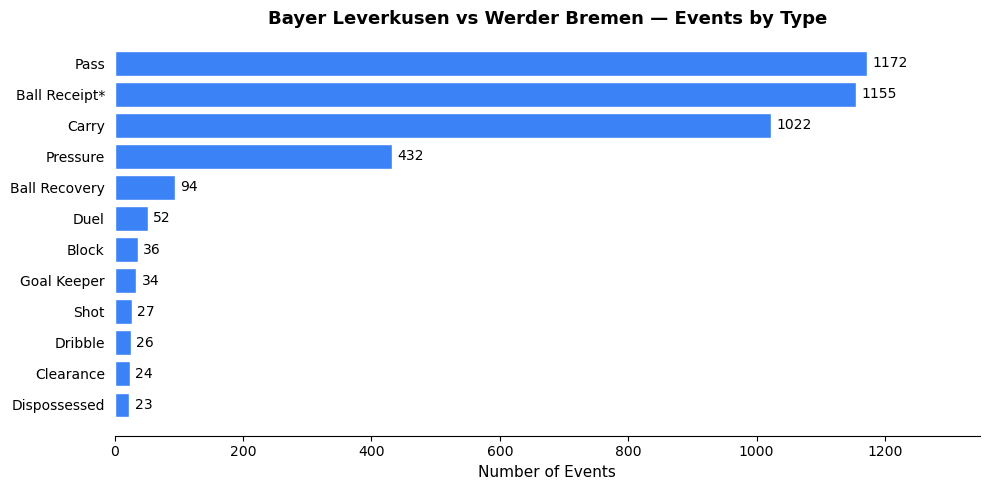

In [12]:
top = event_counts.head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top['Event Type'][::-1], top['Count'][::-1], color='#3b82f6', edgecolor='white')

for bar, val in zip(bars, top['Count'][::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Number of Events', fontsize=11)
ax.set_title(f'{home_team} vs {away_team} — Events by Type', fontsize=13, fontweight='bold')
ax.set_xlim(0, top['Count'].max() * 1.15)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig('figures/event_types_bar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Split by team

In [13]:
by_team = (
    df.groupby(['type', 'team'])
    .size()
    .reset_index(name='count')
    .pivot(index='type', columns='team', values='count')
    .fillna(0).astype(int)
    .sort_values(home_team, ascending=False)
)
by_team

team,Bayer Leverkusen,Werder Bremen
type,,
Pass,651,521
Ball Receipt*,639,516
Carry,587,435
Pressure,220,212
Ball Recovery,54,40
Shot,20,7
Duel,18,34
Block,16,20
Dispossessed,15,8


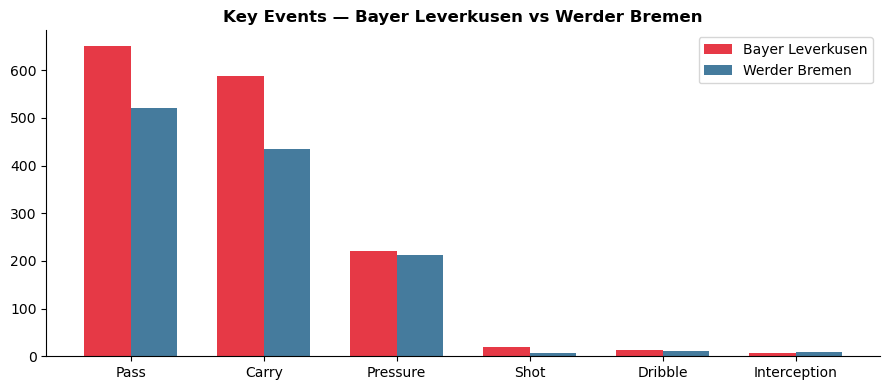

In [14]:
key_types = ['Pass', 'Shot', 'Carry', 'Pressure', 'Dribble', 'Interception']
key = by_team.loc[by_team.index.isin(key_types)]

x = range(len(key))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([i - w/2 for i in x], key[home_team], w, label=home_team, color='#e63946')
ax.bar([i + w/2 for i in x], key[away_team], w, label=away_team, color='#457b9d')
ax.set_xticks(list(x))
ax.set_xticklabels(key.index, fontsize=10)
ax.set_title(f'Key Events — {home_team} vs {away_team}', fontsize=12, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/events_by_team.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Simple queries

In [15]:
# Top passers
passes = df[df['type'] == 'Pass']
passes.groupby(['player', 'team']).size().reset_index(name='passes').sort_values('passes', ascending=False).head(10)

,player,team,passes
26,Robert Andrich,Bayer Leverkusen,88
4,Edmond Fayçal Tapsoba,Bayer Leverkusen,87
8,Granit Xhaka,Bayer Leverkusen,85
22,Odilon Kossonou,Bayer Leverkusen,77
12,Jonathan Tah,Bayer Leverkusen,74
28,Senne Lynen,Werder Bremen,68
2,Christian Groß,Werder Bremen,63
18,Milos Veljkovic,Werder Bremen,61
13,Julián Malatini,Werder Bremen,59
27,Romano Schmid,Werder Bremen,52


In [16]:
# Shots + xG by player
shots = df[df['type'] == 'Shot']
(
    shots.groupby(['player', 'team'])
    .agg(shots=('type', 'count'), xG=('shot_statsbomb_xg', 'sum'))
    .round({'xG': 3})
    .sort_values('shots', ascending=False)
)

,,shots,xG
player,team,,
Florian Wirtz,Bayer Leverkusen,5,0.871
Granit Xhaka,Bayer Leverkusen,3,0.103
Jonathan Tah,Bayer Leverkusen,3,0.192
Victor Okoh Boniface,Bayer Leverkusen,2,1.107
Leonardo Bittencourt,Werder Bremen,2,0.105
Nick Woltemade,Werder Bremen,1,0.082
Romano Schmid,Werder Bremen,1,0.034
Piero Martín Hincapié Reyna,Bayer Leverkusen,1,0.143
Patrik Schick,Bayer Leverkusen,1,0.109


In [17]:
# xG vs actual goals by team
xg = shots.groupby('team')['shot_statsbomb_xg'].sum().round(2)
goals = shots[shots['shot_outcome'] == 'Goal'].groupby('team').size()
result = pd.DataFrame({'xG': xg, 'Goals': goals}).fillna(0)
result['Goals'] = result['Goals'].astype(int)
result['Diff'] = (result['Goals'] - result['xG']).round(2)
result

,xG,Goals,Diff
team,,,
Bayer Leverkusen,3.00,5,2.00
Werder Bremen,0.68,0,-0.68


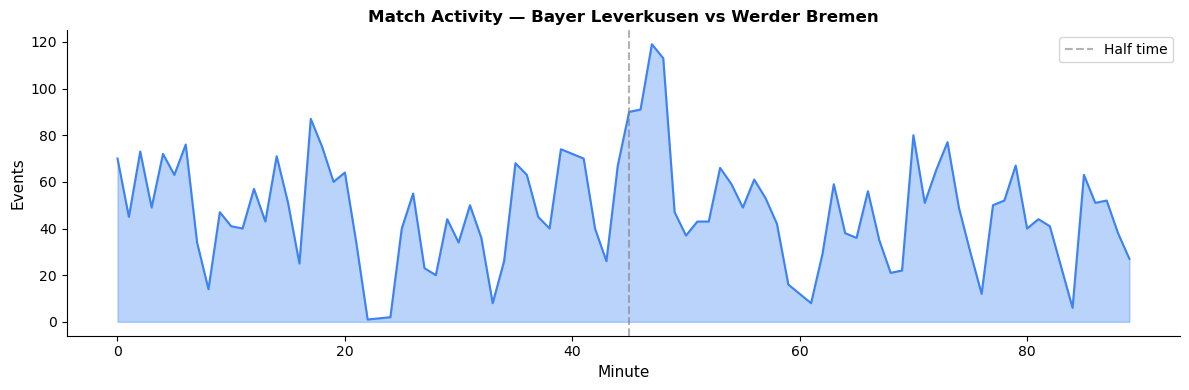

In [18]:
# Activity over time
events_per_min = df.groupby('minute').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(events_per_min.index, events_per_min.values, alpha=0.35, color='#3b82f6')
ax.plot(events_per_min.index, events_per_min.values, color='#3b82f6', linewidth=1.5)
ax.axvline(45, color='gray', linestyle='--', alpha=0.6, label='Half time')
ax.set_xlabel('Minute', fontsize=11)
ax.set_ylabel('Events', fontsize=11)
ax.set_title(f'Match Activity — {home_team} vs {away_team}', fontsize=12, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/events_per_minute.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Pass sub-fields — what's inside a pass?

In [19]:
pass_cols = sorted(c for c in df.columns if c.startswith('pass_'))
for c in pass_cols:
    non_null = df[c].notna().sum()
    print(f'  {c:<40} {non_null:>5} non-null')

  pass_aerial_won                             11 non-null
  pass_angle                                1172 non-null
  pass_assisted_shot_id                       18 non-null
  pass_body_part                            1142 non-null
  pass_cross                                  22 non-null
  pass_cut_back                                1 non-null
  pass_deflected                               3 non-null
  pass_end_location                         1172 non-null
  pass_goal_assist                             4 non-null
  pass_height                               1172 non-null
  pass_inswinging                              3 non-null
  pass_length                               1172 non-null
  pass_outcome                               142 non-null
  pass_outswinging                             3 non-null
  pass_recipient                            1156 non-null
  pass_shot_assist                            14 non-null
  pass_switch                                 21 non-null
  pass_techniq

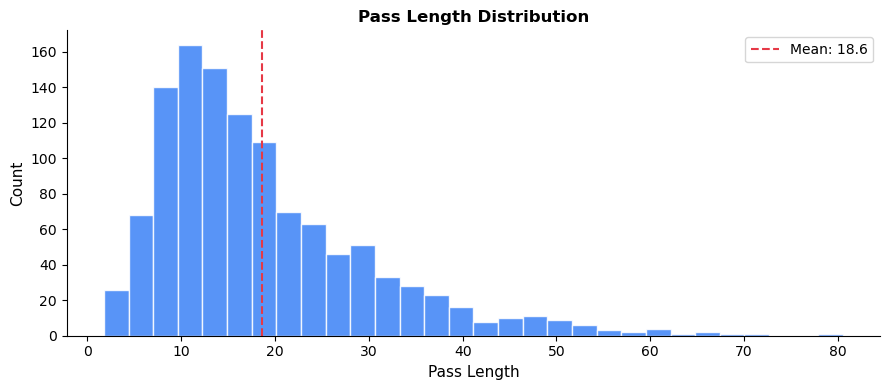

In [20]:
# Pass length distribution
lengths = passes['pass_length'].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=30, color='#3b82f6', edgecolor='white', alpha=0.85)
ax.axvline(lengths.mean(), color='#e63946', linestyle='--', label=f'Mean: {lengths.mean():.1f}')
ax.set_xlabel('Pass Length', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Pass Length Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/pass_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Pass completion rate
outcomes = passes['pass_outcome'].fillna('Complete').value_counts()
print(outcomes)
print(f"\nCompletion rate: {outcomes.get('Complete', 0) / len(passes) * 100:.1f}%")

pass_outcome
Complete        1030
Incomplete       129
Out                7
Pass Offside       4
Unknown            2
Name: count, dtype: int64

Completion rate: 87.9%


---
## Summary

| Topic | What We Covered |
|---|---|
| Data structure | competitions.json → matches → events |
| Event types | ~30 types, Pass + Carry dominate |
| Location data | x/y on a 120×80 pitch |
| Sub-fields | Each type has nested fields (xG, pass length, etc.) |
| Queries | Top passers, xG by team, activity over time |

**Next: [1.2 — Drawing a Football Pitch in Python](../1.2_Pitch_in_Python/notebook.ipynb)**